## 1. Import Libraries

In [1]:
import sys
print(sys.executable)

e:\NLP\sentiment-analysis-product-reviews\.venv\Scripts\python.exe


In [2]:
import pandas as pd

In [3]:
print(pd.__version__)

3.0.5


In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 2. Load the Dataset

In [8]:
import os

train_pos_path = "../data/aclImdb/train/pos"
train_neg_path = "../data/aclImdb/train/neg"

In [9]:
print(os.path.exists(train_pos_path))
print(os.path.exists(train_neg_path))

True
True


In [10]:
positive_files = os.listdir(train_pos_path)

print(positive_files[:5])

['0_9.txt', '10000_8.txt', '10001_10.txt', '10002_7.txt', '10003_8.txt']


In [11]:
first_file = positive_files[0]

with open(
    os.path.join(train_pos_path, first_file),
    "r",
    encoding="utf-8"
) as file:
    first_review = file.read()

print(first_review)

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!


## 3. Build the Training DataFrame

In [12]:
reviews = []
sentiments = []

for filename in os.listdir(train_pos_path):
    file_path = os.path.join(train_pos_path, filename)

    with open(file_path, "r", encoding="utf-8") as file:
        reviews.append(file.read())
        sentiments.append("positive")

for filename in os.listdir(train_neg_path):
    file_path = os.path.join(train_neg_path, filename)

    with open(file_path, "r", encoding="utf-8") as file:
        reviews.append(file.read())
        sentiments.append("negative")

In [13]:
df = pd.DataFrame({
    "review": reviews,
    "sentiment": sentiments
})

In [14]:
df.head()

,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,positive
1,Homelessness (or Houselessness as George Carli...,positive
2,Brilliant over-acting by Lesley Ann Warren. Be...,positive
3,This is easily the most underrated film inn th...,positive
4,This is not the typical Mel Brooks film. It wa...,positive


In [15]:
df.shape

(25000, 2)

In [16]:
df["sentiment"].value_counts()

sentiment
positive    12500
negative    12500
Name: count, dtype: int64

## 4. Explore the Dataset

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     25000 non-null  str  
 1   sentiment  25000 non-null  str  
dtypes: str(2)
memory usage: 390.8 KB


In [18]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [19]:
df["sentiment"].value_counts()

sentiment
positive    12500
negative    12500
Name: count, dtype: int64

## 5. Remove Duplicate Reviews

In [20]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after:", df.duplicated().sum())
print("Dataset shape:", df.shape)

Duplicates before: 96
Duplicates after: 0
Dataset shape: (24904, 2)


In [21]:
df["sentiment"].value_counts()

sentiment
positive    12472
negative    12432
Name: count, dtype: int64

## 6. Text Preprocessing

In [22]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [23]:
sample_review = df["review"].iloc[0]

print("Original Review:")
print(sample_review)

print("\nCleaned Review:")
print(clean_text(sample_review))

Original Review:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!

Cleaned Review:
bromwell high is a cartoon comedy it ran at the same time as some other programs about school life such as teachers my years in the teaching profession lead me

In [24]:
df["clean_review"] = df["review"].apply(clean_text)

In [25]:
df[["review", "clean_review"]].head()

,review,clean_review
0,Bromwell High is a cartoon comedy. It ran at t...,bromwell high is a cartoon comedy it ran at th...
1,Homelessness (or Houselessness as George Carli...,homelessness or houselessness as george carlin...
2,Brilliant over-acting by Lesley Ann Warren. Be...,brilliant over acting by lesley ann warren bes...
3,This is easily the most underrated film inn th...,this is easily the most underrated film inn th...
4,This is not the typical Mel Brooks film. It wa...,this is not the typical mel brooks film it was...


In [26]:
df.shape

(24904, 3)

## 7. Encode Sentiment Labels

In [27]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [28]:
df[["sentiment", "label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,positive,1
4,positive,1


In [29]:
df["label"].value_counts()

label
1    12472
0    12432
Name: count, dtype: int64

## 8. Prepare Features and Target

In [30]:
X = df["clean_review"]
y = df["label"]

In [31]:
print(X.shape)
print(y.shape)

(24904,)
(24904,)


## 9. Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 19923
Testing samples: 4981


In [34]:
print(y_train.value_counts())
print(y_test.value_counts())

label
1    9977
0    9946
Name: count, dtype: int64
label
1    2495
0    2486
Name: count, dtype: int64


## 10. TF-IDF Vectorization

In [35]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

In [36]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [37]:
X_test_tfidf = tfidf.transform(X_test)

In [38]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(19923, 10000)
(4981, 10000)


## 11. Train Logistic Regression Model

In [39]:
model = LogisticRegression(max_iter=1000)

In [40]:
model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## 12. Make Predictions

In [41]:
y_pred = model.predict(X_test_tfidf)

In [42]:
print(y_pred[:20])

[0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 1]


In [43]:
print(y_test.iloc[:20].values)

[0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1]


## 13. Model Evaluation

In [44]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8891788797430235


In [45]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 88.92%


In [46]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.87      0.89      2486
    Positive       0.87      0.91      0.89      2495

    accuracy                           0.89      4981
   macro avg       0.89      0.89      0.89      4981
weighted avg       0.89      0.89      0.89      4981



In [47]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2155  331]
 [ 221 2274]]


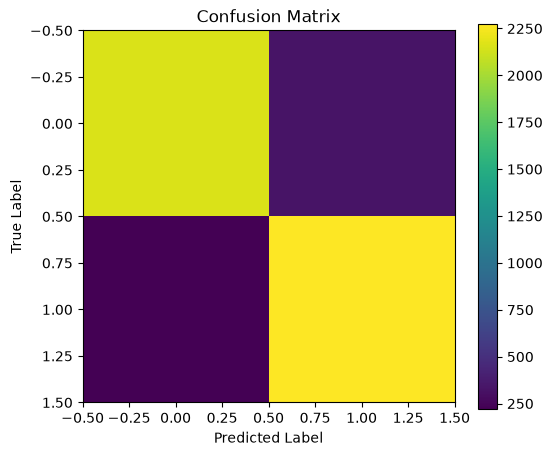

In [48]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

## 14. Custom Sentiment Prediction

In [49]:
def predict_sentiment(review):
    cleaned_review = clean_text(review)

    review_vector = tfidf.transform([cleaned_review])

    prediction = model.predict(review_vector)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [50]:
predict_sentiment(
    "This movie was absolutely amazing and I loved every minute of it."
)

'Positive'

In [51]:
predict_sentiment(
    "This was one of the worst movies I have ever watched."
)

'Negative'

## 15. Classification Report

In [52]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.87      0.89      2486
    Positive       0.87      0.91      0.89      2495

    accuracy                           0.89      4981
   macro avg       0.89      0.89      0.89      4981
weighted avg       0.89      0.89      0.89      4981



## 16. Confusion Matrix

In [55]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2155  331]
 [ 221 2274]]


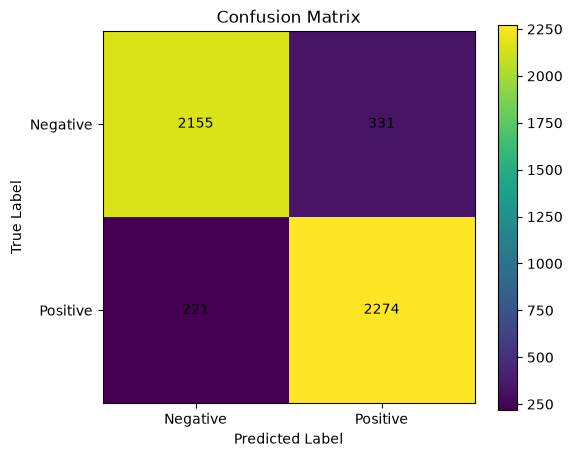

In [56]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 17. Custom Sentiment Prediction

In [57]:
def predict_sentiment(review):
    cleaned_review = clean_text(review)

    review_vector = tfidf.transform([cleaned_review])

    prediction = model.predict(review_vector)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [58]:
predict_sentiment(
    "This movie was amazing and I really enjoyed it."
)

'Positive'

In [59]:
predict_sentiment(
    "This movie was terrible and extremely boring."
)

'Negative'

## 18. Most Frequent Words

In [60]:
positive_reviews = df[df["label"] == 1]["clean_review"]
negative_reviews = df[df["label"] == 0]["clean_review"]

In [61]:
from collections import Counter

def get_most_common_words(reviews, top_n=20):
    all_words = " ".join(reviews).split()
    word_counts = Counter(all_words)

    return word_counts.most_common(top_n)

In [62]:
positive_words = get_most_common_words(positive_reviews)
negative_words = get_most_common_words(negative_reviews)

In [63]:
print("Positive:")
print(positive_words)

print("\nNegative:")
print(negative_words)

Positive:
[('the', 173151), ('and', 89644), ('a', 83672), ('of', 76773), ('to', 66675), ('is', 57190), ('in', 50175), ('it', 48009), ('i', 40706), ('that', 35601), ('this', 35034), ('s', 34035), ('as', 26275), ('with', 23211), ('for', 22387), ('was', 21888), ('film', 20916), ('but', 20809), ('movie', 19050), ('his', 17208)]

Negative:
[('the', 162642), ('a', 79074), ('and', 74066), ('to', 68682), ('of', 68658), ('is', 49860), ('it', 48172), ('i', 46688), ('in', 43544), ('this', 40713), ('that', 37486), ('s', 31863), ('was', 26182), ('movie', 24855), ('for', 21828), ('but', 21675), ('with', 20790), ('as', 20530), ('t', 20500), ('film', 19143)]
